In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001430D074A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001430D140380>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'response_time': 0.67,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph

In [6]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [8]:
## Custom function
def add(a:int,b:int)->int:
    """Add a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a+b

In [9]:
## Custom function
def subtract(a:int,b:int)->int:
    """Subtract b from a

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a-b

In [10]:
tools=[tool,multiply,add,subtract]

In [11]:
llm_using_tools=llm.bind_tools(tools)

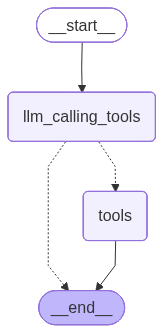

In [14]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def llm_calling_tools(state:State):
    return {"messages":[llm_using_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("llm_calling_tools",llm_calling_tools)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "llm_calling_tools")
builder.add_conditional_edges(
    "llm_calling_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
response=graph.invoke({"messages":"What is the recent news about Apple and also multiply 5 with 6 and add 10 to the result?"})

In [16]:
response['messages'][-1].content

'40'

In [17]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent news about Apple and also multiply 5 with 6 and add 10 to the result?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (dy9rbz9z1)
 Call ID: dy9rbz9z1
  Args:
    query: Apple recent news
    time_range: day
    topic: news
  multiply (5kx35zt48)
 Call ID: 5kx35zt48
  Args:
    a: 5
    b: 6
  add (zpbaz6vzr)
 Call ID: zpbaz6vzr
  Args:
    a: 30
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "Apple recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrumors.com/2026/04/11/iphone-ultra-will-solve-two-key-problems/", "title": "'iPhone Ultra' Will Solve Two Key Problems - MacRumors", "score": 0.93439513, "published_date": "Sat, 11 Apr 2026 15:40:00 GMT", "content": "Apple reportedly plans to unveil a 